# 미니프로젝트: 머신러닝 프로세스 (Vibe Coding)

#### <목표>
오늘 배운 머신러닝 프로세스를 **제조 데이터셋**에 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>
- AI4I 2020 Predictive Maintenance (예지 정비)
- 10,000개 제조 장비 운전 데이터

| 변수명 | 설명 |
|:---:|:---|
| Type | 제품 품질 등급 (L: Low, M: Medium, H: High) |
| Air temperature | 공기 온도 [K] |
| Process temperature | 공정 온도 [K] |
| Rotational speed | 회전 속도 [rpm] |
| Torque | 토크 [Nm] |
| Tool wear | 공구 마모 시간 [min] |
| Machine failure | 기계 고장 여부 (0: 정상, 1: 고장) |
| TWF, HDF, PWF, OSF, RNF | 고장 유형별 발생 여부 |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 회귀 | `Torque` | 운전 조건(온도, 회전속도, 공구마모 등)으로 토크 예측 |
| 분류 | `Machine failure` | 운전 조건으로 기계 고장 여부 예측 |

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day1_miniproject.csv` 파일을 사용하기
- 하나의 원본 데이터에서 태스크별로 데이터프레임을 분리하기
    - **회귀용 (Regression):** 타겟 = `Torque`, 입력 = Type, Air temperature, Process temperature, Rotational speed, Tool wear
    - **분류용 (Classification):** 타겟 = `Machine failure`, 입력 = Type, Air temperature, Process temperature, Rotational speed, Torque, Tool wear

**[과제]** 써니는 오늘부로 제조 설비 운전 데이터를 분석하게 되었습니다. 분석에 필요한 라이브러리를 불러오고, 회귀용/분류용 데이터셋을 각각 어떻게 구성해야 할지 AI와 상의해서 코드를 작성하세요.

In [5]:
# [과제] 라이브러리 불러오기 + 회귀용/분류용 데이터셋 구성

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 그래프에서 한글이 깨지지 않도록 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 원본 데이터 불러오기
raw = pd.read_csv(r"dataset\day1_miniproject.csv")

# TWF, HDF, PWF, OSF, RNF는 특정 고장 유형의 발생 여부를 나타내는 컬럼으로,
# Machine failure(고장 여부)와 사실상 같은 정보를 담고 있어 데이터 누수(Data Leakage) 위험이 있음
# -> 회귀/분류 입력변수에서 모두 제외

# 회귀용 데이터셋: 운전 조건으로 Torque(토크)를 예측
reg_cols = ["Type", "Air temperature", "Process temperature", "Rotational speed", "Tool wear", "Torque"]
Regression = raw[reg_cols].copy()

# 분류용 데이터셋: 운전 조건으로 Machine failure(고장 여부)를 예측
cla_cols = ["Type", "Air temperature", "Process temperature", "Rotational speed", "Torque", "Tool wear", "Machine failure"]
Classification = raw[cla_cols].copy()

print("Regression:", Regression.shape)
print("Classification:", Classification.shape)

Regression.head()


Regression: (10000, 6)
Classification: (10000, 7)


,Type,Air temperature,Process temperature,Rotational speed,Tool wear,Torque
0,M,298.1,308.6,1551,0,42.8
1,L,298.2,308.7,1408,3,46.3
2,L,298.1,308.5,1498,5,49.4
3,L,298.2,308.6,1433,7,39.5
4,L,298.2,308.7,1408,9,40.0


---
## 1) 데이터 탐색 (EDA)

### 1-1) Value 기반 탐색

**[과제]** 써니는 본격적인 분석에 앞서 데이터가 어떻게 생겼는지 먼저 파악하고 싶습니다. AI와 어떠한 데이터 정보를 확인하면 좋을지 상의해보고 관련 정보를 확인해보세요.

In [6]:
# [과제] 데이터 구조 파악하기

# 1) 데이터 구조(행/열 개수, 컬럼별 자료형, 결측치 아닌 값 개수) 한 번에 확인
raw.info()

# 2) 컬럼별 결측치 개수 확인
print("\n컬럼별 결측치 개수")
print(raw.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  object 
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Torque               10000 non-null  float64
 5   Tool wear            10000 non-null  int64  
 6   Machine failure      10000 non-null  int64  
 7   TWF                  10000 non-null  int64  
 8   HDF                  10000 non-null  int64  
 9   PWF                  10000 non-null  int64  
 10  OSF                  10000 non-null  int64  
 11  RNF                  10000 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 937.6+ KB

컬럼별 결측치 개수
Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Torque          

In [7]:
# 3) 수치형 변수의 기술통계 확인 (평균, 표준편차, 최솟값, 최댓값 등)
raw.describe()

# 4) 범주형 변수(Type)의 고유값과 값별 빈도 확인
print(raw["Type"].value_counts())


Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


### 1-2) Graph 기반 탐색

#### 1-2-1) 단일 변수 분포

**[과제]** 써니는 변수들의 분포가 어떤 모양인지 한눈에 살펴보고 싶습니다. 여러 수치형 변수를 효율적으로 한 번에 볼 수 있는 방법을 AI와 상의해서 시각화해 보세요.

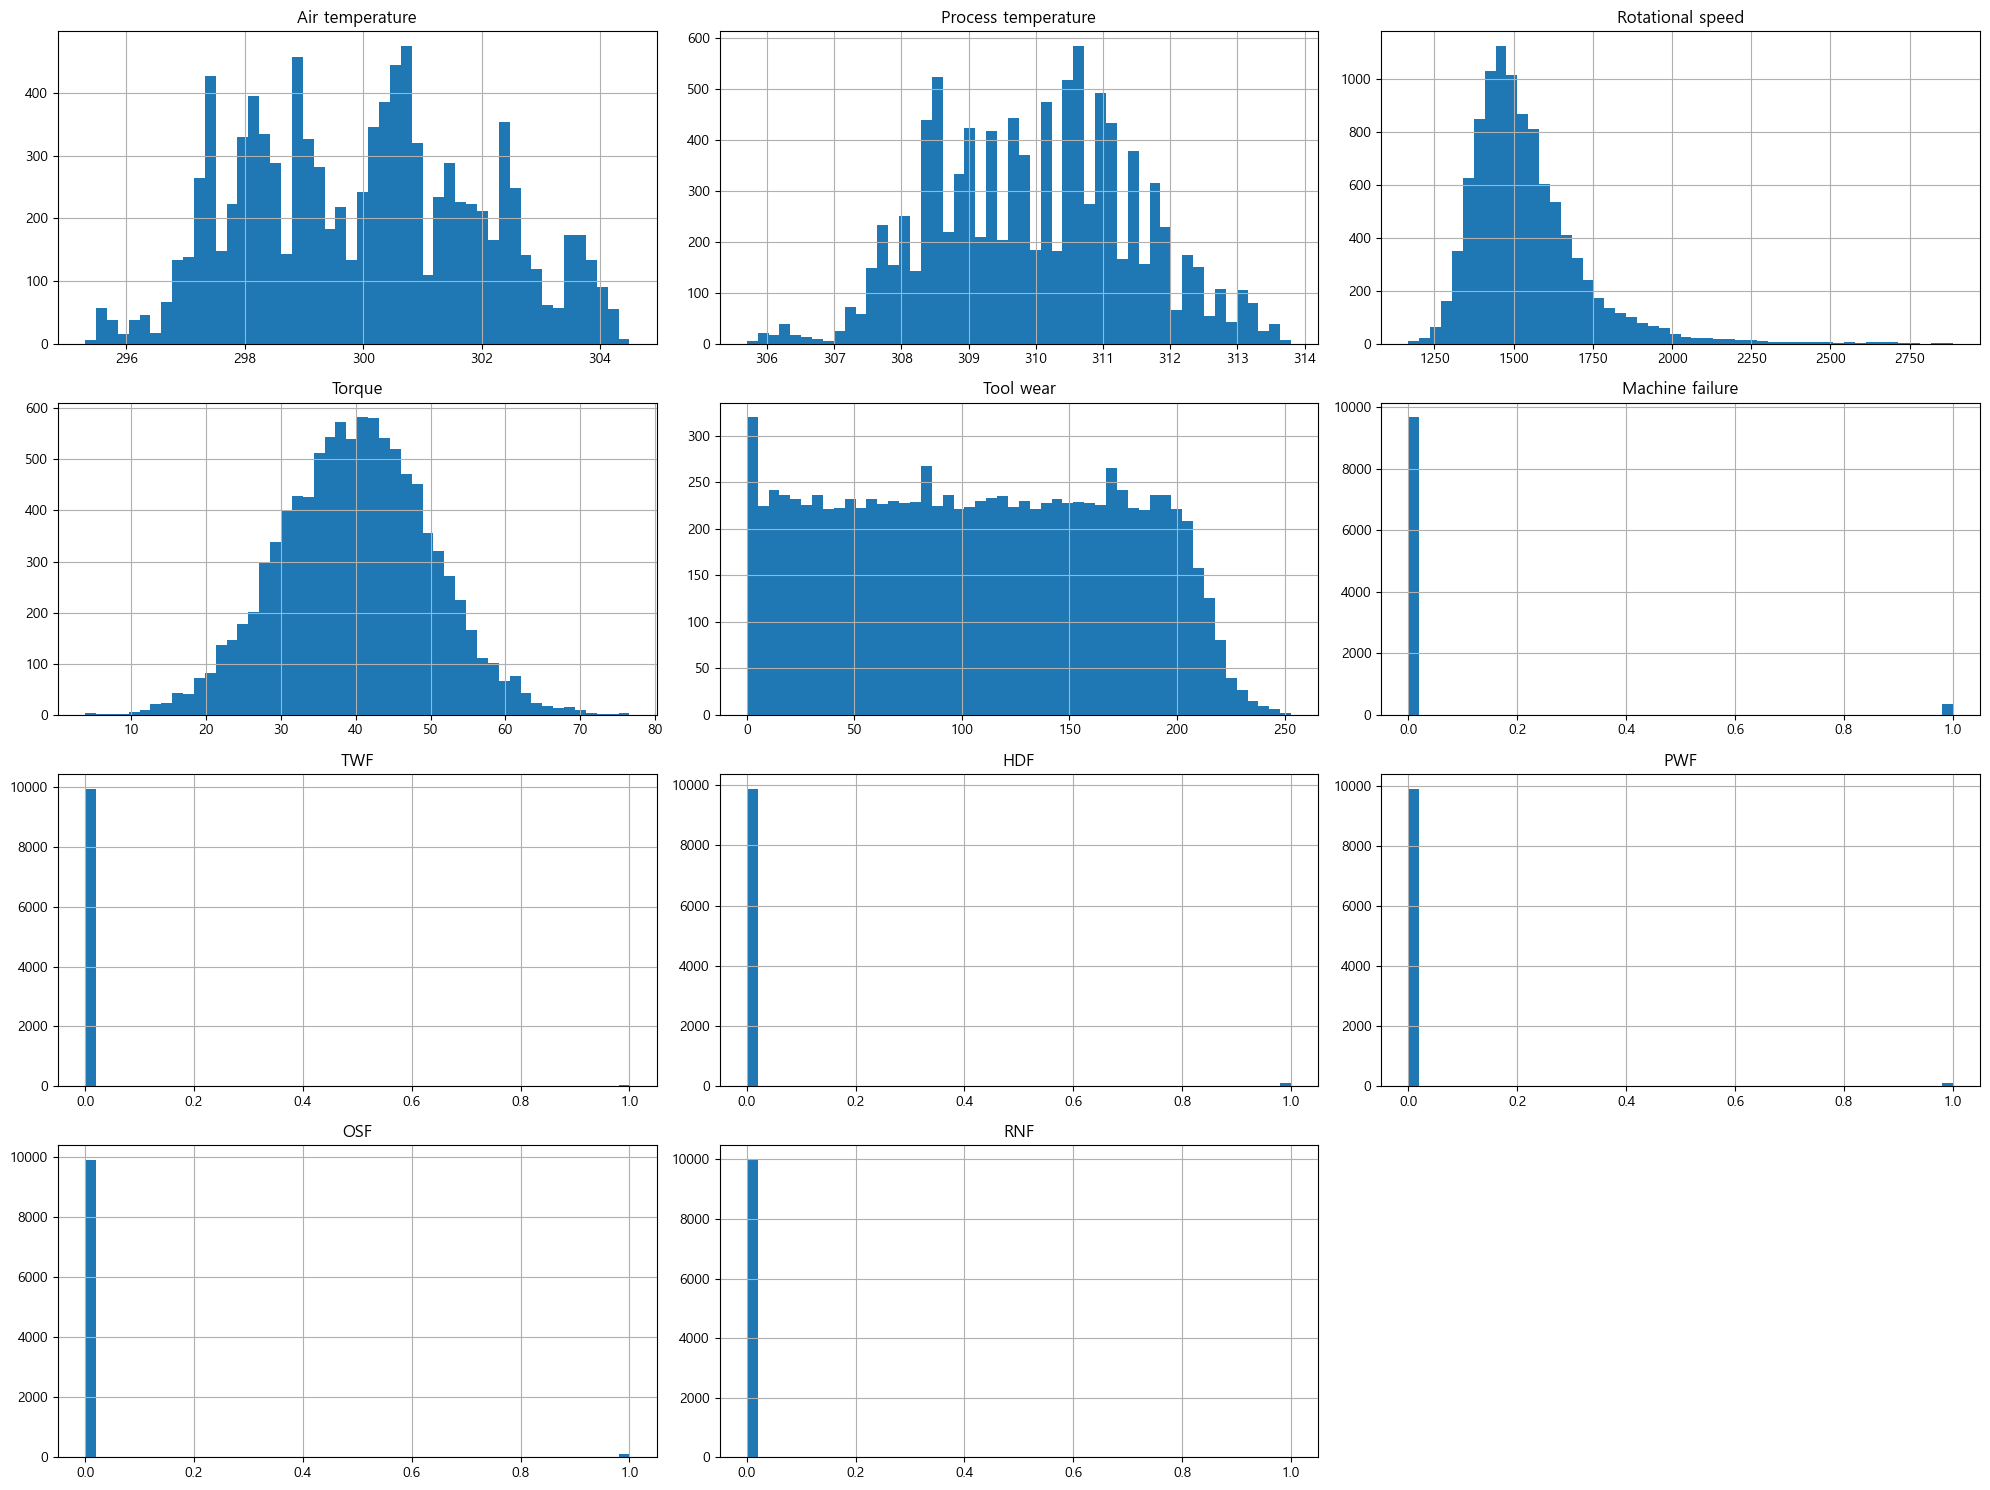

In [8]:
# [과제] 여러 수치형 변수의 분포를 한 번에 시각화하기
# 방법: DataFrame.hist()를 사용하면 컬럼마다 따로 그릴 필요 없이
#       모든 수치형 변수의 히스토그램을 한 번에 그려서 전체 분포를 한눈에 비교할 수 있음

raw.hist(bins=50, figsize=(20, 15))
plt.tight_layout()
plt.show()


**[과제]** 써니는 설비 고장이 실제로 얼마나 자주 발생하는지 궁금합니다. 고장 발생 빈도를 확인할 수 있는 방법을 AI와 함께 찾아보고, 그 결과를 시각화하거나 분석해 보세요. 이 결과가 앞으로의 분석(데이터 분할, 성능 평가 등)에 어떤 영향을 줄 수 있을지도 함께 생각해 보세요.

Machine failure 빈도(개수):
Machine failure
0    9661
1     339
Name: count, dtype: int64

Machine failure 비율(%):
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


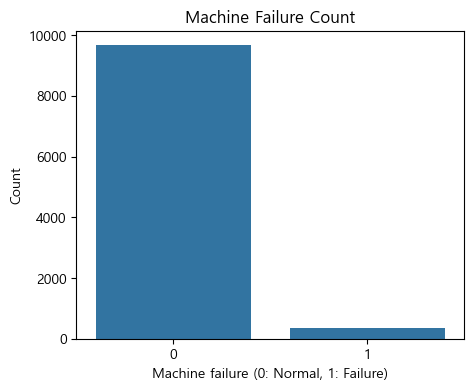

In [9]:
# [과제] 설비 고장 발생 빈도 확인하기

# 1) 고장 여부(Machine failure) 빈도 및 비율 확인
failure_counts = Classification["Machine failure"].value_counts()
failure_ratio = Classification["Machine failure"].value_counts(normalize=True) * 100

print("Machine failure 빈도(개수):")
print(failure_counts)
print("\nMachine failure 비율(%):")
print(failure_ratio.round(2))

# 2) 막대그래프로 시각화
plt.figure(figsize=(5, 4))
sns.countplot(data=Classification, x="Machine failure")
plt.title("Machine Failure Count")
plt.xlabel("Machine failure (0: Normal, 1: Failure)")
plt.ylabel("Count")
plt.show()

# 3) 분석: 클래스 불균형(Class Imbalance) 확인
# -> 고장(1)이 정상(0)에 비해 매우 적은 비율(약 3.4%)로 나타남 (심한 클래스 불균형)
# -> [데이터 분할] train_test_split에 stratify=Y_cla 옵션을 사용해
#    train/test 각각에 정상:고장 비율이 원본과 동일하게 유지되도록 해야 함
# -> [성능 평가] Accuracy만 보면 "무조건 정상"으로 예측해도 96%대가 나올 수 있으므로,
#    Recall, Precision, F1, AUC 등 불균형에 강한 지표를 함께 확인해야 함


**[과제]** 써니는 설비가 고장 났을 때와 정상일 때 변수들의 분포가 어떻게 다른지 비교하고 싶습니다. 어떻게 비교하면 차이가 잘 드러날지 AI와 상의해서 방법을 정하고 직접 시각화해 보세요.

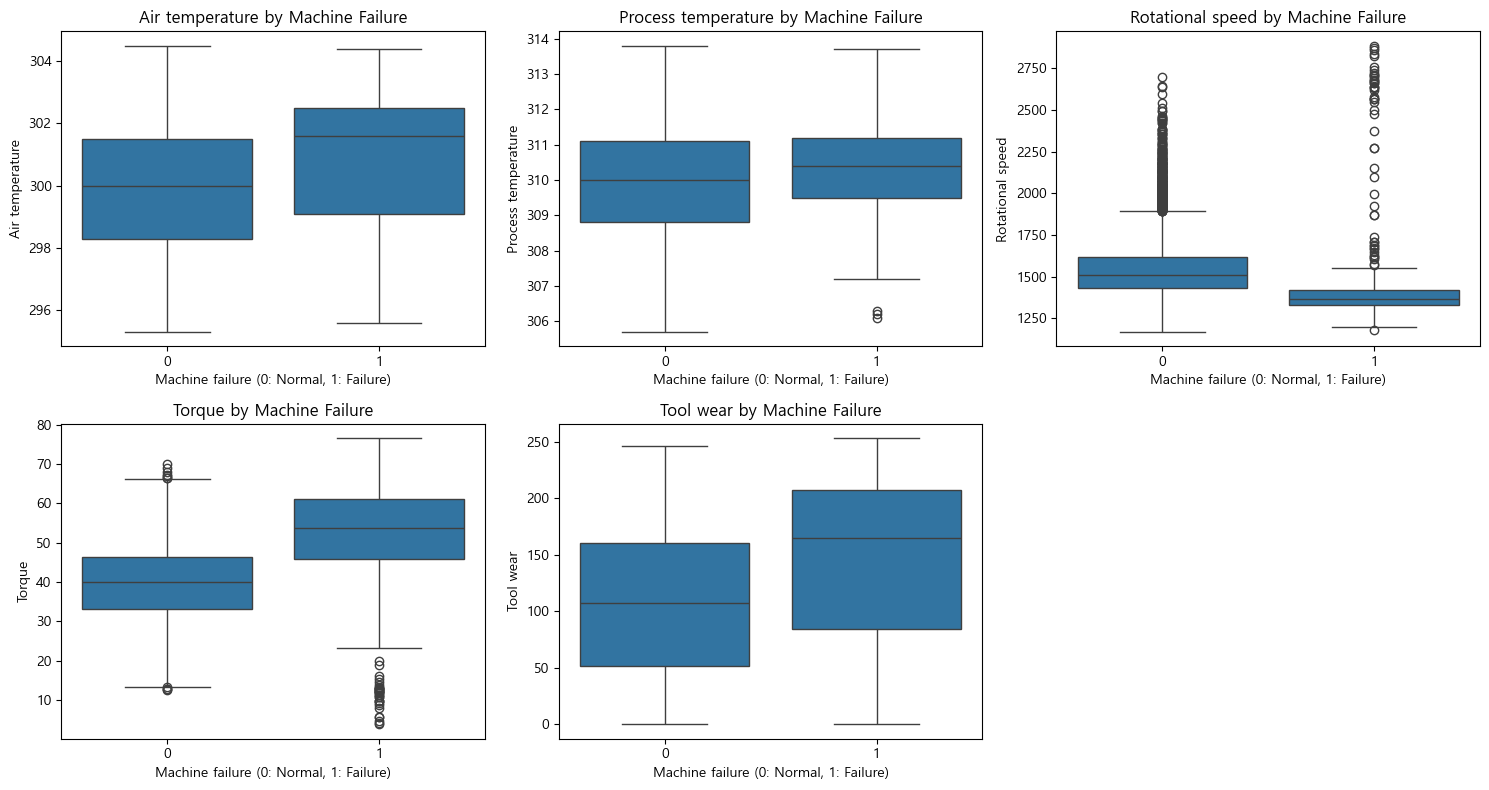

In [11]:
# [과제] 정상(0) vs 고장(1)일 때 변수 분포 비교하기

# 비교할 수치형 변수 목록 (Machine failure 자기 자신은 제외)
compare_cols = ["Air temperature", "Process temperature", "Rotational speed", "Torque", "Tool wear"]

# boxplot을 그리드로 배치해서 정상/고장 그룹별 분포를 한 번에 비교
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(compare_cols):
    sns.boxplot(data=Classification, x="Machine failure", y=col, ax=axes[i])
    axes[i].set_title(f"{col} by Machine Failure")
    axes[i].set_xlabel("Machine failure (0: Normal, 1: Failure)")

# 변수 개수보다 subplot 칸이 많으므로 남는 칸은 숨기기
for j in range(len(compare_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# 분석: 고장(1) 그룹에서 Torque(토크)와 Tool wear(공구 마모도)의 분포가
#       정상(0) 그룹과 비교해 눈에 띄게 다르게(대체로 더 높게) 나타나는지 확인


#### 1-2-2) 변수 간 관계

**[과제]** 써니는 변수들 간에 강하게 얽혀 있는 관계(다중공선성 후보)가 있는지 한눈에 살펴보고 싶습니다. 전체 변수 간 관계를 효율적으로 볼 수 있는 방법을 AI와 상의해서 시각화해 보세요.

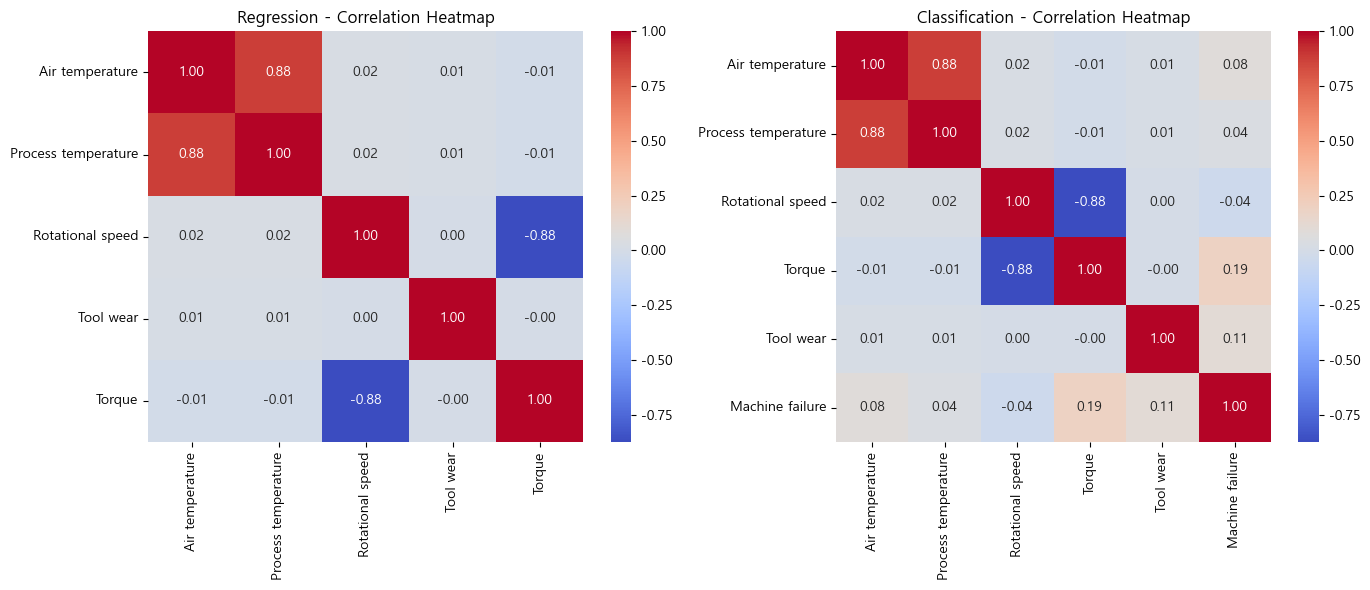

In [12]:
# [과제] 변수 간 상관관계를 히트맵으로 한눈에 살펴보기

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(Regression.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0])
axes[0].set_title("Regression - Correlation Heatmap")

sns.heatmap(Classification.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Classification - Correlation Heatmap")

plt.tight_layout()
plt.show()

# 분석: 색이 진하고 값이 1(또는 -1)에 가까운 칸일수록 두 변수가 강하게 얽혀 있음 (다중공선성 후보)


**[과제]** 써니는 히트맵으로 상관관계가 높은 변수쌍은 찾았지만, 단순한 상관계수만으로 변수들이 서로 얽혀 있는 정도를 다 설명할 수 있을지 의문이 듭니다. 상관계수 외에 변수 간의 강한 관계를 파악할 수 있는 다른 방법이 있는지 AI와 함께 찾아보고, 직접 적용해 보세요.

In [13]:
# [과제] VIF(분산팽창요인)로 다중공선성 진단하기
# VIF = 1 / (1 - R^2)  (R^2: 해당 변수를 나머지 변수들로 예측했을 때의 결정계수)
# 일반적으로 VIF > 10이면 다중공선성이 심각하다고 판단함
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1) Regression 데이터셋의 VIF 계산 (수치형 입력 변수만 사용, Type/Torque 제외)
X_reg = Regression.drop(columns=["Type", "Torque"])

vif_reg = pd.DataFrame()
vif_reg["feature"] = X_reg.columns
vif_reg["VIF"] = [variance_inflation_factor(X_reg.values, i) for i in range(X_reg.shape[1])]
print("[Regression] VIF 결과")
print(vif_reg.sort_values("VIF", ascending=False))

# 2) Classification 데이터셋의 VIF 계산 (수치형 입력 변수만 사용, Type/Machine failure 제외)
X_cla = Classification.drop(columns=["Type", "Machine failure"])

vif_cla = pd.DataFrame()
vif_cla["feature"] = X_cla.columns
vif_cla["VIF"] = [variance_inflation_factor(X_cla.values, i) for i in range(X_cla.shape[1])]
print("\n[Classification] VIF 결과")
print(vif_cla.sort_values("VIF", ascending=False))

# 분석: Air temperature와 Process temperature의 VIF가 매우 높게 나타남
#       -> 히트맵에서 확인한 두 변수 간 높은 상관관계가 실제로 심각한 다중공선성으로 이어짐을 재확인


[Regression] VIF 결과
               feature           VIF
1  Process temperature  87429.317543
0      Air temperature  87381.792106
2     Rotational speed     74.667242
3            Tool wear      3.877080

[Classification] VIF 결과
               feature           VIF
1  Process temperature  88285.242860
0      Air temperature  87413.106376
2     Rotational speed    315.329872
3               Torque     72.125192
4            Tool wear      3.877244


---
## 2) 데이터 전처리

### 2-1) 불필요한 변수 제거 및 결측치 확인

**[과제]** 써니는 모델에 넣기 전에 분석에 도움이 안 되거나, 오히려 결과를 왜곡시킬 수 있는 변수가 있는지 점검하려고 합니다. 어떤 변수를 빼야 하는지, 그 이유는 무엇인지 AI와 상의해서 정리하고 제거해 보세요.

In [14]:
# [과제] 다중공선성 변수 제거 및 결측치 재확인

# 1) 결측치 확인 (이미 raw에서 확인했지만, 실제 사용할 데이터셋 기준으로 재확인)
print("Regression 결측치:\n", Regression.isna().sum())
print("\nClassification 결측치:\n", Classification.isna().sum())

# 2) Air temperature vs Process temperature: 타겟과의 상관관계 비교
corr_reg = Regression.corr(numeric_only=True)["Torque"][["Air temperature", "Process temperature"]]
corr_cla = Classification.corr(numeric_only=True)["Machine failure"][["Air temperature", "Process temperature"]]

print("\n[Regression] Torque와의 상관관계")
print(corr_reg)
print("\n[Classification] Machine failure와의 상관관계")
print(corr_cla)

# 3) 타겟과 상관관계가 더 낮은 변수를 제거
#    - Regression: Process temperature가 근소하게 더 높음 -> Air temperature 제거
#    - Classification: Air temperature가 더 높음 -> Process temperature 제거
Regression = Regression.drop(columns=["Air temperature"])
Classification = Classification.drop(columns=["Process temperature"])

print("\n제거 후 Regression 컬럼:", list(Regression.columns))
print("제거 후 Classification 컬럼:", list(Classification.columns))


Regression 결측치:
 Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Tool wear              0
Torque                 0
dtype: int64

Classification 결측치:
 Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Torque                 0
Tool wear              0
Machine failure        0
dtype: int64

[Regression] Torque와의 상관관계
Air temperature       -0.013778
Process temperature   -0.014061
Name: Torque, dtype: float64

[Classification] Machine failure와의 상관관계
Air temperature        0.082556
Process temperature    0.035946
Name: Machine failure, dtype: float64

제거 후 Regression 컬럼: ['Type', 'Process temperature', 'Rotational speed', 'Tool wear', 'Torque']
제거 후 Classification 컬럼: ['Type', 'Air temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Machine failure']


### 2-2) 데이터 분할

**[과제]** 써니는 학습/테스트 데이터를 나누려고 합니다. 회귀용과 분류용 각각에 어떤 분할 방법과 기준이 적합할지 AI와 상의해서 정하고, 그 기준대로 직접 나눠 보세요.

In [15]:
# [과제] 학습/테스트 데이터 분할하기
from sklearn.model_selection import train_test_split

# 1) Regression: 입력(X)과 타겟(y) 분리 후 일반 무작위 분할 (stratify 불필요: 연속형 타겟)
X_reg = Regression.drop(columns=["Torque"])
y_reg = Regression["Torque"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 2) Classification: 입력(X)과 타겟(y) 분리 후 stratify로 클래스 비율 유지
X_cla = Classification.drop(columns=["Machine failure"])
y_cla = Classification["Machine failure"]

X_cla_train, X_cla_test, y_cla_train, y_cla_test = train_test_split(
    X_cla, y_cla, test_size=0.2, random_state=42, stratify=y_cla
)

print("Regression train/test shape:", X_reg_train.shape, X_reg_test.shape)
print("Classification train/test shape:", X_cla_train.shape, X_cla_test.shape)

# 3) stratify 적용 확인: 원본/train/test의 고장 비율이 비슷하게 유지되는지 확인
print("\n원본 고장 비율:", y_cla.mean().round(4))
print("Train 고장 비율:", y_cla_train.mean().round(4))
print("Test 고장 비율:", y_cla_test.mean().round(4))


Regression train/test shape: (8000, 4) (2000, 4)
Classification train/test shape: (8000, 5) (2000, 5)

원본 고장 비율: 0.0339
Train 고장 비율: 0.0339
Test 고장 비율: 0.034


### 2-3) 변수 스케일링

**[과제]** 써니는 수치형 변수들의 스케일이 제각각이라 모델 학습 전에 맞춰주고 싶습니다. 변수들의 분포를 보면서 어떤 스케일링 기법이 적합할지 AI와 상의해서 정하고 적용해 보세요.

In [16]:
# [과제] 변수 스케일링 (StandardScaler)
# 이상치가 존재하므로 MinMaxScaler보다 이상치 영향이 적은 StandardScaler를 사용
# 데이터 누수 방지를 위해 X_train에만 fit하고, X_train/X_test 모두 transform
from sklearn.preprocessing import StandardScaler

# Type은 아직 숫자가 아닌 범주형 변수이므로 스케일링 대상에서 제외 (인코딩은 다음 과제에서 진행)
reg_num_cols = X_reg_train.drop(columns=["Type"]).columns
cla_num_cols = X_cla_train.drop(columns=["Type"]).columns

# 1) Regression 스케일링
scaler_reg = StandardScaler()
X_reg_train[reg_num_cols] = scaler_reg.fit_transform(X_reg_train[reg_num_cols])
X_reg_test[reg_num_cols] = scaler_reg.transform(X_reg_test[reg_num_cols])

# 2) Classification 스케일링
scaler_cla = StandardScaler()
X_cla_train[cla_num_cols] = scaler_cla.fit_transform(X_cla_train[cla_num_cols])
X_cla_test[cla_num_cols] = scaler_cla.transform(X_cla_test[cla_num_cols])

print("스케일링 후 Regression train 통계:")
print(X_reg_train[reg_num_cols].describe().loc[["mean", "std"]])
print("\n스케일링 후 Classification train 통계:")
print(X_cla_train[cla_num_cols].describe().loc[["mean", "std"]])


스케일링 후 Regression train 통계:
      Process temperature  Rotational speed     Tool wear
mean        -2.343170e-14      1.811884e-16  9.414691e-17
std          1.000063e+00      1.000063e+00  1.000063e+00

스케일링 후 Classification train 통계:
      Air temperature  Rotational speed        Torque     Tool wear
mean     1.758593e-15      3.010925e-16 -1.474376e-16 -3.064216e-17
std      1.000063e+00      1.000063e+00  1.000063e+00  1.000063e+00


**[과제]** 써니는 `Type` 변수를 모델에 넣으려면 숫자로 바꿔야 한다는 건 알고 있지만, 원-핫 인코딩과 라벨 인코딩 중 어느 쪽이 맞을지 고민입니다. 어떤 기준으로 선택해야 할지 AI와 상의해서 정하고 적용해 보세요.

In [17]:
# [과제] Type 변수 라벨 인코딩
# Type은 L(Low) < M(Medium) < H(High) 순서가 있는 변수이므로 라벨 인코딩 사용
type_order = {"L": 0, "M": 1, "H": 2}

X_reg_train["Type"] = X_reg_train["Type"].map(type_order)
X_reg_test["Type"] = X_reg_test["Type"].map(type_order)

X_cla_train["Type"] = X_cla_train["Type"].map(type_order)
X_cla_test["Type"] = X_cla_test["Type"].map(type_order)

print("Regression Type 인코딩 결과:")
print(X_reg_train["Type"].value_counts().sort_index())
print("\nClassification Type 인코딩 결과:")
print(X_cla_train["Type"].value_counts().sort_index())


Regression Type 인코딩 결과:
Type
0    4776
1    2422
2     802
Name: count, dtype: int64

Classification Type 인코딩 결과:
Type
0    4830
1    2381
2     789
Name: count, dtype: int64


---
## 3) 모델링

### 3-1) 모델 생성 및 학습

**[과제]** 써니는 여러 모델의 성능을 한 번에 비교해보고 싶습니다. 회귀와 분류 각각 어떤 모델을 후보로 둘지, 매번 코드를 새로 짜지 않고 효율적으로 비교할 방법은 무엇일지 AI와 상의해서 코드를 작성해 보세요.

In [18]:
# [과제] 여러 모델을 딕셔너리로 관리하고 한 번에 학습시키기
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# 1) 회귀 모델 후보들을 딕셔너리로 정의
reg_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "RandomForest": RandomForestRegressor(random_state=0),
    "XGBoost": XGBRegressor(random_state=0),
    "CatBoost": CatBoostRegressor(random_state=0, verbose=0),
}

# 2) 분류 모델 후보들을 딕셔너리로 정의
cla_models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(random_state=0),
    "XGBoost": XGBClassifier(random_state=0),
    "CatBoost": CatBoostClassifier(random_state=0, verbose=0),
}

# 3) .items()로 (모델이름, 모델객체)를 함께 꺼내서 반복 학습
for name, model in reg_models.items():
    model.fit(X_reg_train, y_reg_train)
    print(f"[Regression] {name} 학습 완료")

print()

for name, model in cla_models.items():
    model.fit(X_cla_train, y_cla_train)
    print(f"[Classification] {name} 학습 완료")


[Regression] LinearRegression 학습 완료
[Regression] Ridge 학습 완료
[Regression] Lasso 학습 완료
[Regression] RandomForest 학습 완료
[Regression] XGBoost 학습 완료
[Regression] CatBoost 학습 완료

[Classification] Logistic 학습 완료
[Classification] RandomForest 학습 완료
[Classification] XGBoost 학습 완료
[Classification] CatBoost 학습 완료


### 3-2) 테스트 데이터 예측

**[과제]** 써니는 앞서 학습시킨 회귀 및 분류 모델들로 테스트 데이터에 대한 예측을 수행하려고 합니다. 모든 모델의 예측 결과를 한 번에 뽑을 수 있도록 AI와 함께 코드를 작성해 보세요.

In [19]:
# [과제] 모든 모델로 테스트 데이터 예측하고 결과를 딕셔너리로 모으기

# 1) 회귀 모델별 예측값을 {모델이름: 예측값} 형태로 저장
reg_preds = {}
for name, model in reg_models.items():
    reg_preds[name] = model.predict(X_reg_test)

# 2) 분류 모델별 예측값을 {모델이름: 예측값} 형태로 저장
cla_preds = {}
for name, model in cla_models.items():
    cla_preds[name] = model.predict(X_cla_test)

print("회귀 모델 예측 결과 (앞 5개):")
for name, pred in reg_preds.items():
    print(f"{name}: {pred[:5]}")

print("\n분류 모델 예측 결과 (앞 5개):")
for name, pred in cla_preds.items():
    print(f"{name}: {pred[:5]}")


회귀 모델 예측 결과 (앞 5개):
LinearRegression: [40.02983723 45.71007234 42.51558047 37.57352061 24.24863263]
Ridge: [40.02983374 45.7093355  42.51530795 37.57378734 24.25059337]
Lasso: [40.0411028  45.05823211 42.3138195  37.72550466 26.0188696 ]
RandomForest: [38.029 46.537 41.777 33.942 24.194]
XGBoost: [36.47224  45.66718  43.081436 34.673435 24.2455  ]
CatBoost: [37.43865338 45.92338264 41.42995656 34.51498665 24.55970224]

분류 모델 예측 결과 (앞 5개):
Logistic: [1 0 0 0 0]
RandomForest: [0 0 0 0 0]
XGBoost: [0 0 0 0 0]
CatBoost: [0 0 0 0 0]


### 3-3) 성능 평가

**[과제]** 써니는 모델 성능을 비교하려고 하는데, 회귀와 분류 각각 사용할 수 있는 지표가 다양해서 무엇을 기준으로 봐야 할지 고민입니다. 적절한 지표를 AI와 상의해서 정하고, 그 기준으로 가장 좋은 모델을 선택해 보세요.

In [20]:
# [과제] 성능 평가 지표 계산 및 비교
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# 1) 회귀 모델 성능 평가 (MAE, MSE, R2)
reg_scores = []
for name, pred in reg_preds.items():
    mae = mean_absolute_error(y_reg_test, pred)
    mse = mean_squared_error(y_reg_test, pred)
    r2 = r2_score(y_reg_test, pred)
    reg_scores.append({"Model": name, "MAE": mae, "MSE": mse, "R2": r2})

reg_score_df = pd.DataFrame(reg_scores).sort_values("MAE")
print("[Regression] 모델별 성능 비교 (MAE 오름차순)")
print(reg_score_df)

# 2) 분류 모델 성능 평가 (Accuracy, Recall, Precision, F1, AUC)
cla_scores = []
for name, model in cla_models.items():
    pred = cla_preds[name]
    proba = model.predict_proba(X_cla_test)[:, 1]   # AUC 계산용 고장(1) 확률

    acc = accuracy_score(y_cla_test, pred)
    rec = recall_score(y_cla_test, pred)
    prec = precision_score(y_cla_test, pred)
    f1 = f1_score(y_cla_test, pred)
    auc = roc_auc_score(y_cla_test, proba)
    cla_scores.append({"Model": name, "Accuracy": acc, "Recall": rec, "Precision": prec, "F1": f1, "AUC": auc})

cla_score_df = pd.DataFrame(cla_scores).sort_values("F1", ascending=False)
print("\n[Classification] 모델별 성능 비교 (F1 내림차순)")
print(cla_score_df)

# 3) 가장 좋은 모델 선택
best_reg_model_name = reg_score_df.iloc[0]["Model"]
best_cla_model_name = cla_score_df.iloc[0]["Model"]
print(f"\n최고 성능 회귀 모델: {best_reg_model_name}")
print(f"최고 성능 분류 모델: {best_cla_model_name}")


[Regression] 모델별 성능 비교 (MAE 오름차순)
              Model       MAE        MSE        R2
5          CatBoost  3.042357  16.782336  0.829717
4           XGBoost  3.138328  17.750342  0.819895
3      RandomForest  3.140733  17.404615  0.823403
0  LinearRegression  3.683322  23.957612  0.756912
1             Ridge  3.683471  23.958068  0.756908
2             Lasso  3.884402  25.305759  0.743233

[Classification] 모델별 성능 비교 (F1 내림차순)
          Model  Accuracy    Recall  Precision        F1       AUC
3      CatBoost    0.9770  0.455882   0.775000  0.574074  0.972476
2       XGBoost    0.9745  0.455882   0.688889  0.548673  0.958402
1  RandomForest    0.9750  0.426471   0.725000  0.537037  0.959315
0      Logistic    0.9685  0.132353   0.692308  0.222222  0.883784

최고 성능 회귀 모델: CatBoost
최고 성능 분류 모델: CatBoost


---
## 4) 모델 고도화

**[과제]** 써니는 가장 성능이 좋았던 모델을 더 끌어올리고 싶습니다. 어떤 하이퍼파라미터를 어느 범위까지 탐색하면 좋을지 AI와 상의해서 정하고, 그 기준으로 성능을 높여 보세요.

In [21]:
# [과제] 최고 성능 모델(CatBoost) 하이퍼파라미터 튜닝
from sklearn.model_selection import RandomizedSearchCV

# CatBoost는 파라미터 종류와 값의 범위가 넓으므로 RandomizedSearchCV 사용
param_dist_cat = {
    "iterations": [200, 300, 500],
    "depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7],
}

# 1) 회귀용 CatBoost 튜닝 (평가 지표: MAE 기준 -> neg_mean_absolute_error)
random_cat_reg = RandomizedSearchCV(
    CatBoostRegressor(random_state=0, verbose=0),
    param_dist_cat,
    n_iter=10,     # 무작위로 10개 조합만 시도
    cv=5,          # 10,000행 정도의 중간 크기 데이터 -> 5-fold 교차검증
    scoring="neg_mean_absolute_error",
    random_state=0,
    n_jobs=-1,
)
random_cat_reg.fit(X_reg_train, y_reg_train)

print("[Regression] 최적 파라미터:", random_cat_reg.best_params_)
print("[Regression] 최적 MAE (교차검증 평균):", -random_cat_reg.best_score_)

# 2) 분류용 CatBoost 튜닝 (평가 지표: F1 기준, 클래스 불균형 고려)
random_cat_cla = RandomizedSearchCV(
    CatBoostClassifier(random_state=0, verbose=0),
    param_dist_cat,
    n_iter=10,
    cv=5,
    scoring="f1",
    random_state=0,
    n_jobs=-1,
)
random_cat_cla.fit(X_cla_train, y_cla_train)

print("\n[Classification] 최적 파라미터:", random_cat_cla.best_params_)
print("[Classification] 최적 F1 (교차검증 평균):", random_cat_cla.best_score_)

# 3) 튜닝된 모델로 테스트 데이터 재평가
best_reg_model = random_cat_reg.best_estimator_
best_cla_model = random_cat_cla.best_estimator_

tuned_reg_pred = best_reg_model.predict(X_reg_test)
tuned_cla_pred = best_cla_model.predict(X_cla_test)

print("\n[Regression] 튜닝 후 테스트 MAE:", mean_absolute_error(y_reg_test, tuned_reg_pred))
print("[Regression] 튜닝 전 CatBoost 테스트 MAE:", reg_score_df[reg_score_df["Model"] == "CatBoost"]["MAE"].values[0])

print("\n[Classification] 튜닝 후 테스트 F1:", f1_score(y_cla_test, tuned_cla_pred))
print("[Classification] 튜닝 전 CatBoost 테스트 F1:", cla_score_df[cla_score_df["Model"] == "CatBoost"]["F1"].values[0])


[Regression] 최적 파라미터: {'learning_rate': 0.05, 'l2_leaf_reg': 1, 'iterations': 300, 'depth': 4}
[Regression] 최적 MAE (교차검증 평균): 2.942019759740597

[Classification] 최적 파라미터: {'learning_rate': 0.1, 'l2_leaf_reg': 3, 'iterations': 200, 'depth': 4}
[Classification] 최적 F1 (교차검증 평균): 0.601337211052269

[Regression] 튜닝 후 테스트 MAE: 3.0033329344510324
[Regression] 튜닝 전 CatBoost 테스트 MAE: 3.0423569700442994

[Classification] 튜닝 후 테스트 F1: 0.5283018867924528
[Classification] 튜닝 전 CatBoost 테스트 F1: 0.5740740740740741


---
## 5) 모델 결과 분석

**[과제]** 써니는 최종적으로 어떤 운전 조건이 토크와 고장에 가장 큰 영향을 미치는지 정리해서 보고하려고 합니다. 회귀와 분류 각각에서 성능이 가장 좋았던 모델의 변수 중요도를 구하고 시각화하는 방법을 AI와 함께 알아본 뒤, 그 결과로부터 인사이트를 도출해 보세요.

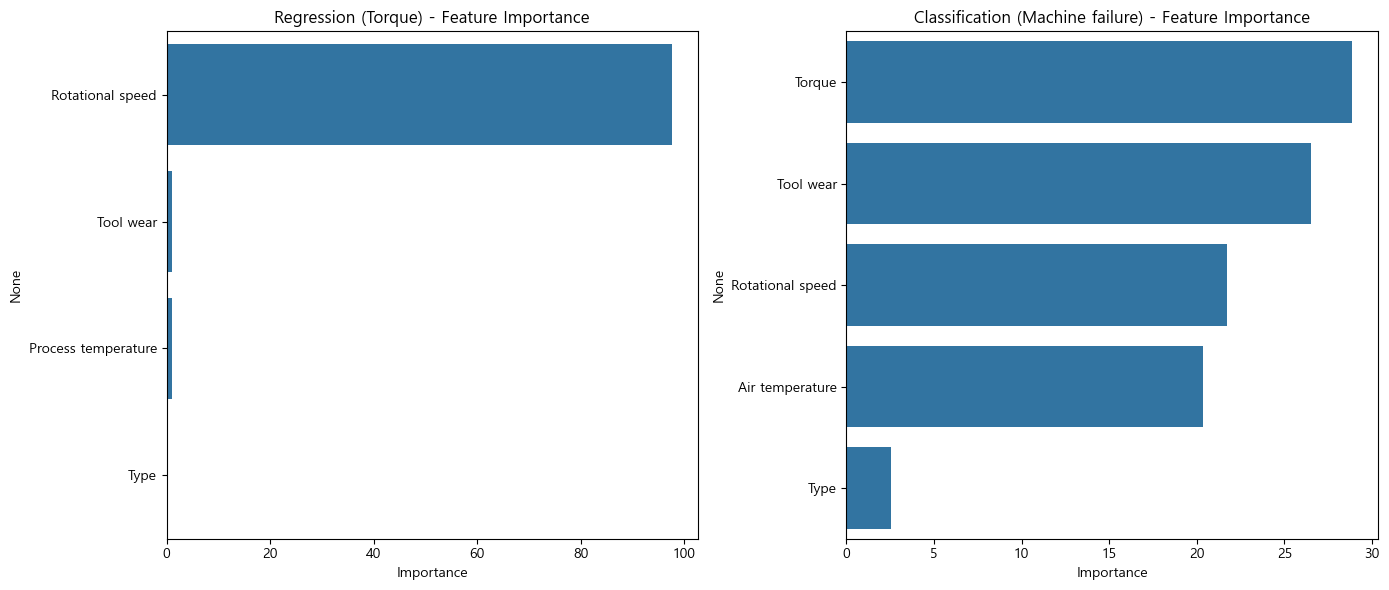

[Regression] 변수 중요도 순위:
Rotational speed       97.717926
Tool wear               1.094152
Process temperature     0.990973
Type                    0.196949
dtype: float64

[Classification] 변수 중요도 순위:
Torque              28.873937
Tool wear           26.503399
Rotational speed    21.715059
Air temperature     20.343471
Type                 2.564134
dtype: float64


In [22]:
# [과제] 변수 중요도(Feature Importance) 분석
# 회귀/분류 모두 최고 성능 모델이 CatBoost(트리 기반)이므로 둘 다 feature_importances_ 사용

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1) 회귀(Torque 예측) 변수 중요도
reg_importance = pd.Series(best_reg_model.feature_importances_, index=X_reg_train.columns)
reg_importance = reg_importance.sort_values(ascending=False)
sns.barplot(x=reg_importance.values, y=reg_importance.index, ax=axes[0])
axes[0].set_title("Regression (Torque) - Feature Importance")
axes[0].set_xlabel("Importance")

# 2) 분류(Machine failure 예측) 변수 중요도
cla_importance = pd.Series(best_cla_model.feature_importances_, index=X_cla_train.columns)
cla_importance = cla_importance.sort_values(ascending=False)
sns.barplot(x=cla_importance.values, y=cla_importance.index, ax=axes[1])
axes[1].set_title("Classification (Machine failure) - Feature Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

print("[Regression] 변수 중요도 순위:")
print(reg_importance)
print("\n[Classification] 변수 중요도 순위:")
print(cla_importance)

# 인사이트:
# - Torque 예측에는 어떤 운전 조건이 가장 크게 기여하는지,
# - Machine failure 예측에는 어떤 운전 조건이 고장 여부를 가장 잘 설명하는지
#   위 순위를 바탕으로 정리해볼 수 있음
